# Analysis of skills centrality based on final GBN classification
Felix Zaussinger | 29.08.2022 (updated on 01.09.2022 with up-to-date coreness measure)

**Core Analysis Goal(s)**
1. Use updated centrality measures
2. Analyse differences in centrality between GBN occupations
3. Visualise (boxplots, test statistics)

**Key Insight(s)**
1.
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from brokenaxes import brokenaxes

# NOTE: added 26.09.2023 to faciliate running script
# os.chdir(os.path.expanduser("T:\\Documents\\Projects\\04_jrc_green-skills-regional\\03_data-analysis\\re4gt"))

# needed for relative import in jupyter lab
module_path = os.path.abspath(os.path.join(os.pardir, os.pardir))
if module_path not in sys.path:
    sys.path.append(module_path)

from src import utils, plotting_utils, stats_utils
#import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

In [2]:
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": "3",
}

Read final classifications

In [3]:
df_sl = pd.read_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists.csv",
    ),
    index_col=0,
)

df_sl_tobi = pd.read_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists_tobi.csv",
    ),
    index_col=0,
)

np.all(df_sl_tobi.gbn_classification_short_list == df_sl.gbn_classification_short_list)

False

#### Merge emission intensive and hard to abate occupations in one df

In [4]:
# merge short list and short list tobi
dfm = pd.merge(df_sl, df_sl_tobi[['conceptUri', 'gbn_classification_short_list']], how='left', on='conceptUri', suffixes=['_sl', '_slt'])

# green occupations: number should be the same for both lists (n=91)
cond_lowcarbon = (dfm.gbn_classification_short_list_sl == 'green') & (dfm.gbn_classification_short_list_slt == 'green')

# neutral occupations: the correct reference is the short list (more neutral ones)
cond_neutral = (dfm.gbn_classification_short_list_sl == 'neutral')

# emission-intensive occupations: the correct reference is the short list (more brown ones) --> super set
cond_emissionintensive = (dfm.gbn_classification_short_list_sl == 'brown')

# hard-to-abate occupations: the correct reference is the short list tobi (less brown ones) --> sub set of above
cond_hardtoabate = (dfm.gbn_classification_short_list_slt == 'brown')

# create single classification column
dfm['expert_classification'] = np.nan
dfm.loc[cond_lowcarbon, 'expert_classification'] = "low-carbon"
dfm.loc[cond_neutral, 'expert_classification'] = "neutral"
dfm.loc[cond_emissionintensive, 'expert_classification'] = "potential-to-abate"
dfm.loc[cond_hardtoabate, 'expert_classification'] = "hard-to-abate"

# overview stats
print(np.unique(dfm.gbn_classification_short_list_sl, return_counts=True))
print(np.unique(dfm.gbn_classification_short_list_slt, return_counts=True))
print(np.unique(dfm.expert_classification, return_counts=True))

# save
dfm.to_csv(
     os.path.join(
        useful_paths.data_processed, "esco", "esco_level_gbn_classification_merged.csv"
    )
)

dfm.info()

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_11368\2213922411.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'low-carbon' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dfm.loc[cond_lowcarbon, 'expert_classification'] = "low-carbon"


(array(['brown', 'green', 'neutral'], dtype=object), array([ 207,   91, 2710], dtype=int64))
(array(['brown', 'green', 'neutral'], dtype=object), array([  63,   91, 2854], dtype=int64))
(array(['hard-to-abate', 'low-carbon', 'neutral', 'potential-to-abate'],
      dtype=object), array([  63,   91, 2710,  144], dtype=int64))
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3008 entries, 0 to 3007
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   conceptUri                         3008 non-null   object
 1   preferredLabel                     3008 non-null   object
 2   description                        3008 non-null   object
 3   gbn_classification_esco            3008 non-null   object
 4   gbn_classification_esco_ess        3007 non-null   object
 5   gbn_classification_short_list_sl   3008 non-null   object
 6   gbn_classification_short_list_slt  3008 non-null   object
 

In [5]:
# plot as stacked bar chart
dfm.groupby('expert_classification').count()

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list_sl,gbn_classification_short_list_slt
expert_classification,,,,,,,
hard-to-abate,63,63,63,63,63,63,63
low-carbon,91,91,91,91,91,91,91
neutral,2710,2710,2710,2710,2709,2710,2710
potential-to-abate,144,144,144,144,144,144,144


Read UPDATED skills data (ESCO v1.1) with coreness

In [6]:
from src.data.framework import Esco

esco = Esco()
smd = pd.read_pickle(
    os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.pkl")
)

In [7]:
smd.columns

Index(['conceptType', 'conceptUri', 'skillType', 'reuseLevel',
       'preferredLabel', 'altLabels', 'hiddenLabels', 'status', 'modifiedDate',
       'scopeNote', 'definition', 'inScheme', 'description',
       'eigenvector_centrality', 'betweenness_centrality',
       'betweenness_centrality_norm', 'mean_centrality',
       'clustering_coefficient', 'coreness', 'skill_classification_esco'],
      dtype='object')

#### Check transversal skills - understand why coreness so low

In [8]:
smd.loc[smd.reuseLevel == 'transversal'].to_csv(
    os.path.join(
        useful_paths.data_processed, "esco", "esco_transversal_skills_network_metrics.csv"
    )
)

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype

cross-sector vs. sector-specific: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=1.577e+03
cross-sector vs. transversal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.336e-241 Stat=1.100e+03
cross-sector vs. occupation-specific: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=5.104e+03


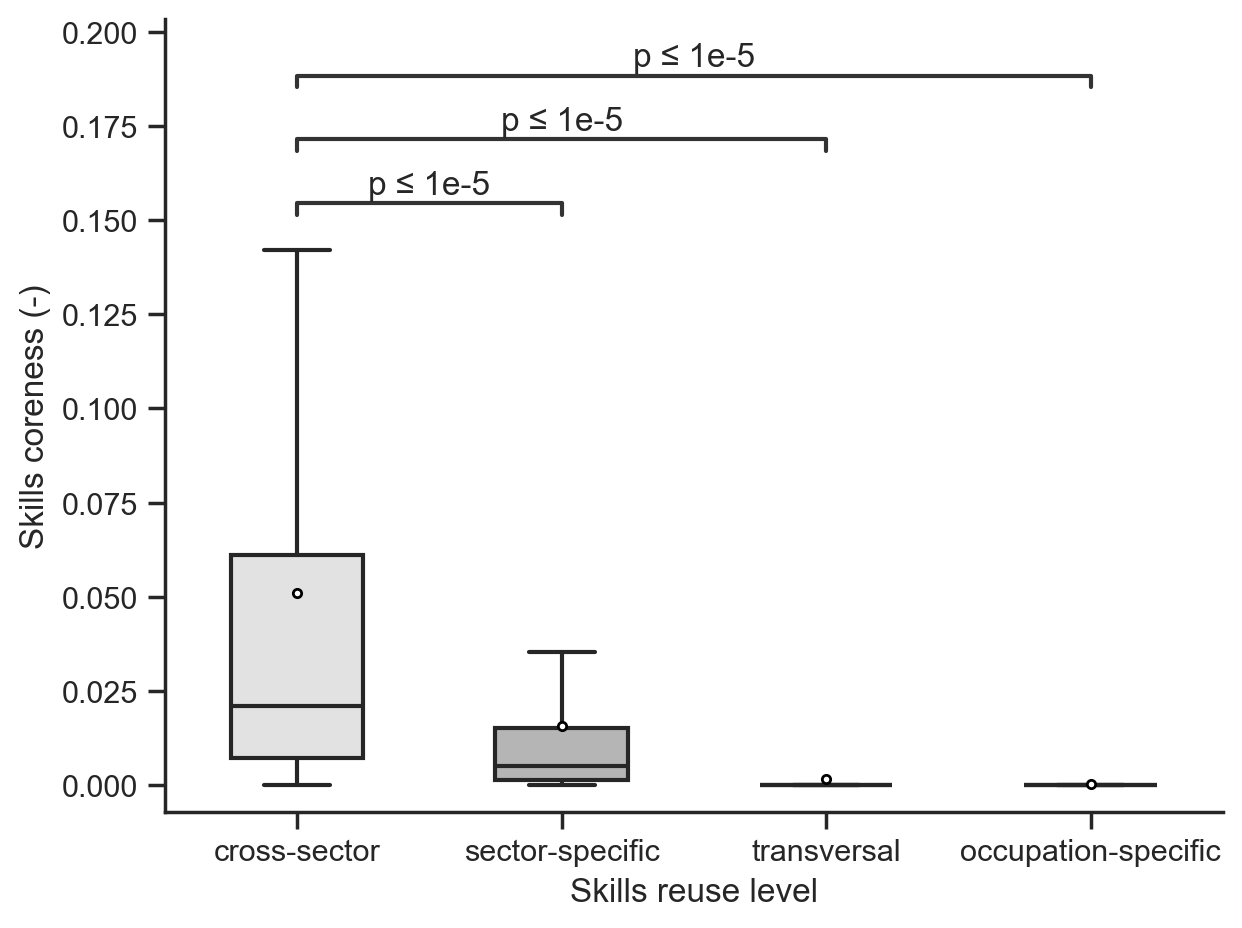

In [9]:
# configure
y = "coreness"
x = "reuseLevel"
df = smd
num_cols = ['eigenvector_centrality', 'betweenness_centrality',
    'betweenness_centrality_norm', 'mean_centrality',
    'clustering_coefficient', 'coreness']
order = (
    smd.groupby("reuseLevel")[num_cols]
    .mean()
    .sort_values("coreness", ascending=False)
    .index.values
)
pairs = [
    ("cross-sector", "sector-specific"),
    ("cross-sector", "transversal"),
    ("cross-sector", "occupation-specific"),
]

# plot
ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    fliersize=1,
    order=order,
    showmeans=True,
    meanprops=meanprops,
    width=0.5,
    showfliers=False,
    palette="Greys",
)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="simple",
    loc="inside",
    show_test_name=False,
)
annotator.apply_and_annotate()

# label
ax.set_xlabel("Skills reuse level")
ax.set_ylabel("Skills coreness (-)")

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir, "skills_centrality", "coreness_by_reuse_level.png"
    ),
    dpi=300,
)

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


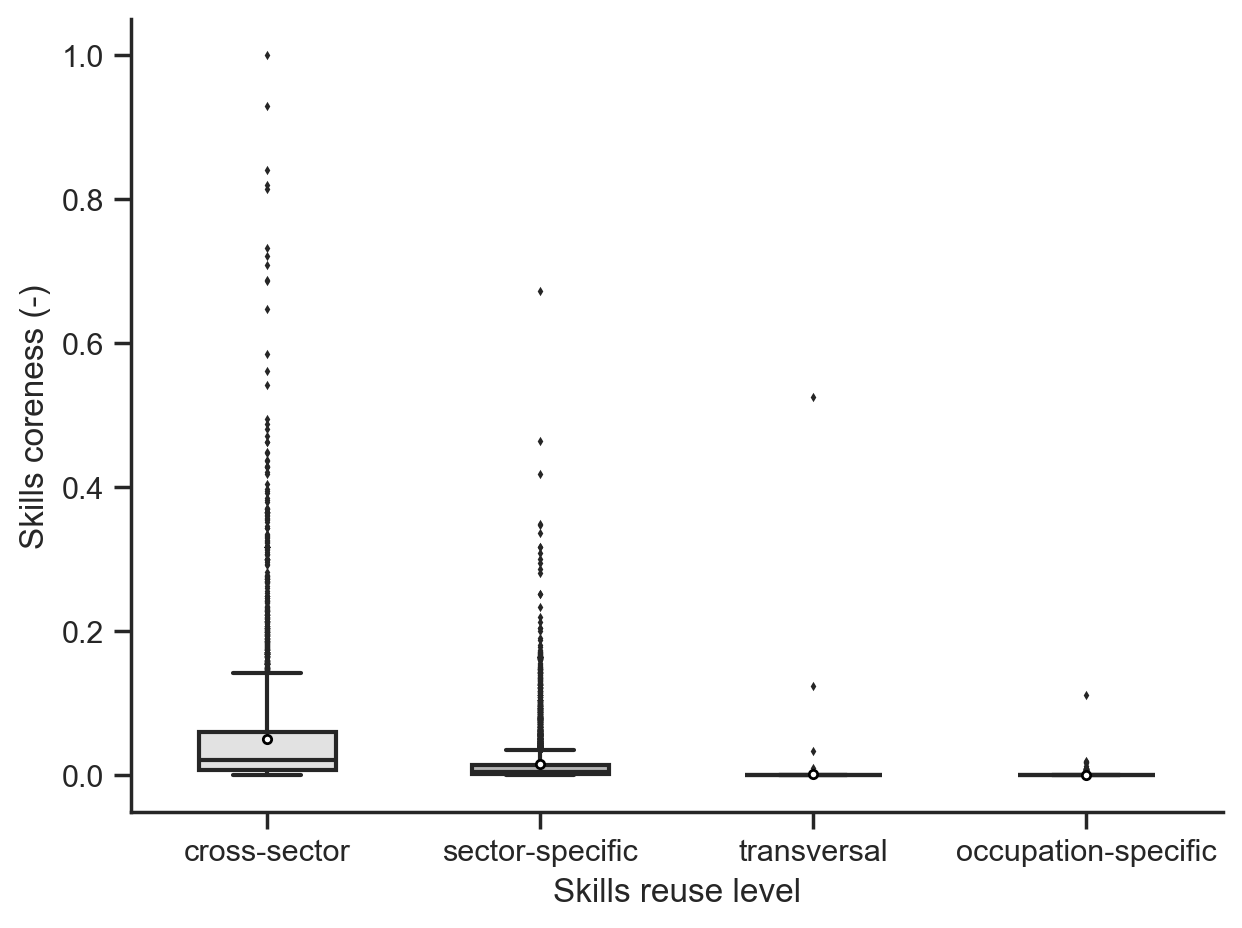

In [10]:
# configure
y = "coreness"
x = "reuseLevel"
df = smd
num_cols = ['eigenvector_centrality', 'betweenness_centrality',
    'betweenness_centrality_norm', 'mean_centrality',
    'clustering_coefficient', 'coreness']
order = (
    smd.groupby("reuseLevel")[num_cols]
    .mean()
    .sort_values("coreness", ascending=False)
    .index.values
)

# plot
ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    fliersize=1,
    order=order,
    showmeans=True,
    meanprops=meanprops,
    width=0.5,
    showfliers=True,
    palette="Greys",
)
sns.despine()

# label
ax.set_xlabel("Skills reuse level")
ax.set_ylabel("Skills coreness (-)")

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir, "skills_centrality", "coreness_by_reuse_level_outliers.png"
    ),
    dpi=300,
)

Missing coreness values
- updated coreness for all skills!

In [11]:
utils.perc_missing(smd)

,missing_obs_abs,missing_obs_rel
conceptType,0.0,0.000000
conceptUri,0.0,0.000000
skillType,1.0,0.000072
reuseLevel,0.0,0.000000
preferredLabel,0.0,0.000000
altLabels,634.0,0.045641
hiddenLabels,13782.0,0.992153
status,0.0,0.000000
modifiedDate,0.0,0.000000
scopeNote,13665.0,0.983730


In [12]:
smd.groupby("skill_classification_esco").count()

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness
skill_classification_esco,,,,,,,,,,,,,,,,,,,
brown,477,477,477,477,477,476,0,477,477,5,0,477,477,477,477,477,477,462,477
green,570,570,570,570,570,526,1,570,570,7,0,570,570,570,570,570,570,558,570
neutral,12844,12844,12843,12844,12844,12255,108,12844,12844,214,3,12844,12844,12844,12844,12844,12844,12001,12844


Read occupation-skills matrices

In [13]:
osm_wtd = esco.read_occ_skills_matrix(return_version="weighted", weight_optional=0.5)
osm_uniform = esco.read_occ_skills_matrix(return_version="unweighted")

In [14]:
np.unique(osm_wtd.values.flatten())

array([0. , 0.5, 1. ])

Combine coreness with OSMs

In [15]:
osm = osm_wtd
assert np.all(osm.columns.values == smd.conceptUri.values)

coreness_tiled = np.tile(smd.coreness.values, (3008, 1))
osm_coreness = osm.mul(coreness_tiled)

In [16]:
df_sl_ridx = df_sl.set_index("conceptUri").reindex(index=osm_coreness.index)
(osm.index == df_sl_ridx.index).all()

True

In [17]:
df_slt_ridx = df_sl_tobi.set_index("conceptUri").reindex(index=osm_coreness.index)
(osm.index == df_slt_ridx.index).all()

df_slt_ridx = df_slt_ridx.rename(
    columns={"gbn_classification_short_list": "gbn_classification_short_list_tobi"}
)

Same with new DF, expert classification

In [18]:
dfm_ridx = dfm.set_index("conceptUri").reindex(index=osm_coreness.index)
(osm.index == dfm_ridx.index).all()

True

In [19]:
dfm_ridx.index

Index(['http://data.europa.eu/esco/occupation/00030d09-2b3a-4efd-87cc-c4ea39d27c34',
       'http://data.europa.eu/esco/occupation/000e93a3-d956-4e45-aacb-f12c83fedf84',
       'http://data.europa.eu/esco/occupation/0019b951-c699-4191-8208-9822882d150c',
       'http://data.europa.eu/esco/occupation/0022f466-426c-41a4-ac96-a235c945cf97',
       'http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f',
       'http://data.europa.eu/esco/occupation/0044c991-c26f-4261-a213-4bd1c0564a4c',
       'http://data.europa.eu/esco/occupation/00634fc4-802a-461b-8af0-499273756f99',
       'http://data.europa.eu/esco/occupation/00674f21-2f8f-4a41-9896-133f7cbe2a6e',
       'http://data.europa.eu/esco/occupation/006cc1f9-2841-41c3-991a-dc3f2f3bd533',
       'http://data.europa.eu/esco/occupation/00747307-6341-4266-a061-25416f7c6a96',
       ...
       'http://data.europa.eu/esco/occupation/ff3a164d-4045-4511-a472-49093dabf9fc',
       'http://data.europa.eu/esco/occupation/ff42d44c

Choice of brown list --> differentiation no longer needed

In [20]:
gbn_clsf = "expert_classification"
df = dfm
df

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list_sl,gbn_classification_short_list_slt,expert_classification
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,Technical directors realise the artistic visio...,neutral,neutral,neutral,neutral,neutral
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,Video and motion picture directors are respons...,neutral,neutral,neutral,neutral,neutral
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,Performance lighting directors determine what ...,neutral,neutral,neutral,neutral,neutral
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,Animation directors supervise and recruit mult...,neutral,neutral,neutral,neutral,neutral
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,Video and motion picture producers supervise t...,neutral,neutral,neutral,neutral,neutral
...,...,...,...,...,...,...,...,...
3003,http://data.europa.eu/esco/occupation/b059d331...,hawker,Hawkers sell goods and services on established...,neutral,neutral,neutral,neutral,neutral
3004,http://data.europa.eu/esco/occupation/96a0d8d3...,quick service restaurant crew member,"Quick service restaurant crew members prepare,...",neutral,neutral,neutral,neutral,neutral
3005,http://data.europa.eu/esco/occupation/a02a1117...,pizzaiolo,Pizzaiolos are responsible for preparing and c...,neutral,neutral,neutral,neutral,neutral
3006,http://data.europa.eu/esco/occupation/e1cf6897...,kitchen assistant,Kitchen assistants assist in the preparation o...,neutral,neutral,neutral,neutral,neutral


In [21]:
df

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list_sl,gbn_classification_short_list_slt,expert_classification
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,Technical directors realise the artistic visio...,neutral,neutral,neutral,neutral,neutral
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,Video and motion picture directors are respons...,neutral,neutral,neutral,neutral,neutral
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,Performance lighting directors determine what ...,neutral,neutral,neutral,neutral,neutral
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,Animation directors supervise and recruit mult...,neutral,neutral,neutral,neutral,neutral
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,Video and motion picture producers supervise t...,neutral,neutral,neutral,neutral,neutral
...,...,...,...,...,...,...,...,...
3003,http://data.europa.eu/esco/occupation/b059d331...,hawker,Hawkers sell goods and services on established...,neutral,neutral,neutral,neutral,neutral
3004,http://data.europa.eu/esco/occupation/96a0d8d3...,quick service restaurant crew member,"Quick service restaurant crew members prepare,...",neutral,neutral,neutral,neutral,neutral
3005,http://data.europa.eu/esco/occupation/a02a1117...,pizzaiolo,Pizzaiolos are responsible for preparing and c...,neutral,neutral,neutral,neutral,neutral
3006,http://data.europa.eu/esco/occupation/e1cf6897...,kitchen assistant,Kitchen assistants assist in the preparation o...,neutral,neutral,neutral,neutral,neutral


In [22]:
osm

conceptUri,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,http://data.europa.eu/esco/skill/00064735-8fad-454b-90c7-ed858cc993f2,http://data.europa.eu/esco/skill/000709ed-2be5-4193-b056-45a97698d828,http://data.europa.eu/esco/skill/0007bdc2-dd15-4824-b7d6-416522c46f35,http://data.europa.eu/esco/skill/00090cc1-1f27-439e-a4e0-19a87a501bfc,http://data.europa.eu/esco/skill/000bb1e4-89f0-4b86-be05-05ece3641724,http://data.europa.eu/esco/skill/000c94d2-2a2e-4545-993c-6df8cb5b0316,http://data.europa.eu/esco/skill/000f1d3d-220f-4789-9c0a-cc742521fb02,http://data.europa.eu/esco/skill/001115fb-569f-4ee6-8381-c6807ef2527f,http://data.europa.eu/esco/skill/001d46db-035e-4b92-83a3-ed8771e0c123,http://data.europa.eu/esco/skill/0023e7a5-43da-4b68-bee3-726ef21f986d,http://data.europa.eu/esco/skill/00298d97-3dc3-4086-a902-bce0a2fba831,http://data.europa.eu/esco/skill/002b2e58-35ab-460c-be97-ca2f585fd990,http://data.europa.eu/esco/skill/0037c821-2898-4919-b96e-7ed1cd89554c,http://data.europa.eu/esco/skill/004017c9-0337-4f5a-8077-798de9ef12e3,http://data.europa.eu/esco/skill/004f1e68-9ca2-4f3f-92d9-e7d7ff6b9330,http://data.europa.eu/esco/skill/00506f28-e884-4496-800c-3477c67eb355,http://data.europa.eu/esco/skill/0058526a-11e9-40a1-ab33-7c5ffdf5da05,http://data.europa.eu/esco/skill/00735755-adc6-4ea0-b034-b8caff339c9f,http://data.europa.eu/esco/skill/0082c13b-5866-4542-bc4f-722a4ae9530e,http://data.europa.eu/esco/skill/00831ebb-bac3-4bd1-8dae-2bca67be958d,http://data.europa.eu/esco/skill/0085e6bd-6829-4e8e-b302-842a7fe57ed9,http://data.europa.eu/esco/skill/008a0e0d-7380-4b31-abe5-0195e700f8c0,http://data.europa.eu/esco/skill/008fa98b-dba6-4abf-909e-04299728e3eb,http://data.europa.eu/esco/skill/00920055-eb50-4cb8-a23d-3deedbf3753e,http://data.europa.eu/esco/skill/009673d9-e2fd-46ef-a64b-6027ac7fd613,http://data.europa.eu/esco/skill/00994812-ac9e-4856-954b-f71bcc6066bb,http://data.europa.eu/esco/skill/009db49b-fcf5-4409-b4a5-232d059f3597,http://data.europa.eu/esco/skill/00a4e92d-e410-42b8-ba2d-d7b3febf49e0,http://data.europa.eu/esco/skill/00b9a3aa-7070-4bb5-8020-f228a97cf42f,http://data.europa.eu/esco/skill/00c04e40-35ea-4ed1-824c-82f936c8f876,http://data.europa.eu/esco/skill/00c51318-4ea9-4d37-9cd8-74680583d203,http://data.europa.eu/esco/skill/00c85cbc-2b24-4605-a6fe-55b5c615e3fe,http://data.europa.eu/esco/skill/00cd1d60-782f-48e7-9a7b-b518f2b146b8,http://data.europa.eu/esco/skill/00dd3271-077f-4a12-a958-e297fdd724ce,http://data.europa.eu/esco/skill/00e261cc-669c-4b94-8950-d038eceb92d8,http://data.europa.eu/esco/skill/00e53a0a-c0ba-4c9f-a2ed-4706d5832a00,http://data.europa.eu/esco/skill/00e895f4-b9d3-4a1a-8c36-baf10fbfb982,http://data.europa.eu/esco/skill/00eada7f-0b83-4f0c-af81-d7f92d838000,http://data.europa.eu/esco/skill/00ebb379-ce26-439a-ba89-9a7d1ef2f696,http://data.europa.eu/esco/skill/00ec5333-e570-477b-9017-2e95fea0150a,http://data.europa.eu/esco/skill/00eefa32-9f77-4500-abe9-20afc7924a9d,http://data.europa.eu/esco/skill/00f12ec1-b416-4e3c-8ed7-c4f875c6b681,http://data.europa.eu/esco/skill/00f2eee1-cd4d-4a45-ae10-b6060f53ad5d,http://data.europa.eu/esco/skill/00fc7575-0cee-4b12-ade5-795cb2a4479a,http://data.europa.eu/esco/skill/00ff06cc-103f-4c85-b5df-6f75acff6abf,http://data.europa.eu/esco/skill/011711eb-f20b-4d64-84d7-17b8979946dc,http://data.europa.eu/esco/skill/0121ac3b-775b-4faf-b86d-0078623674bc,http://data.europa.eu/esco/skill/01267c89-b27f-4de0-b555-3683c5a5d66e,http://data.europa.eu/esco/skill/012795fe-5f85-4d12-a10e-9dabda4ea05f,http://data.europa.eu/esco/skill/012d6406-016a-4790-aeb8-853e61058517,http://data.europa.eu/esco/skill/012f9ad1-b95b-42f1-b2c7-3793cdbce443,http://data.europa.eu/esco/skill/0132ac4f-ffac-4396-8b56-052fde0c9d73,http://data.europa.eu/esco/skill/013441c1-1f13-47e9-80c4-9a53e8e1bc05,http://data.europa.eu/esco/skill/0138fdc7-edbb-485c-9aa9-544f723eb62f,http://data.europa.eu/esco/skill/013a64b9-5e74-4f7f-af5b-9ec76715238b,http://data.europa.eu/esco/skill/01468114-b99c-4f48-9374-a520a7faa9c9

In [23]:
colsel = ["preferredLabel", gbn_clsf]
#osm_merged = pd.concat([osm, df[colsel]], axis=1)
osm_merged = osm.copy()
osm_merged = osm.join(df.set_index('conceptUri'))

In [24]:
osm_merged_v1 = osm_merged.reset_index().set_index(
    ["conceptUri", "preferredLabel", gbn_clsf]
)

n_ess = (
    osm_merged_v1[osm_merged_v1 == 1]
    .count(axis=1)
    .rename("essential")
    .reset_index()
    .set_index("conceptUri")
)
n_opt = (
    osm_merged_v1[osm_merged_v1 == 0.5]
    .count(axis=1)
    .rename("optional")
    .reset_index()
    .set_index("conceptUri")
)

In [25]:
n_ess

,preferredLabel,expert_classification,essential
conceptUri,,,
http://data.europa.eu/esco/occupation/00030d09-2b3a-4efd-87cc-c4ea39d27c34,technical director,neutral,8
http://data.europa.eu/esco/occupation/000e93a3-d956-4e45-aacb-f12c83fedf84,metal drawing machine operator,potential-to-abate,15
http://data.europa.eu/esco/occupation/0019b951-c699-4191-8208-9822882d150c,precision device inspector,neutral,14
http://data.europa.eu/esco/occupation/0022f466-426c-41a4-ac96-a235c945cf97,air traffic safety technician,neutral,15
http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f,hospitality revenue manager,neutral,19
...,...,...,...
http://data.europa.eu/esco/occupation/ff656b3a-65a8-4b4f-b04e-9db12936519b,demographer,neutral,40
http://data.europa.eu/esco/occupation/ff8d4065-db44-47c7-a4bd-51b3c306ef70,sorter labourer,low-carbon,10
http://data.europa.eu/esco/occupation/ffa4dd5d-702b-4828-ad85-17ec50db6656,armoured car guard,neutral,14


#### Differences in number of skills

In [55]:
osm_numeric = osm_merged_v1.select_dtypes(include='number')

n_skills_by_cat = (
    osm_numeric[osm_numeric > 0]
    .count(axis=1)
    .rename("total")
    .reset_index()
    .set_index("conceptUri")
)
n_skills_by_cat["essential"] = n_ess["essential"]
n_skills_by_cat["optional"] = n_opt["optional"]
n_skills_by_cat_long = n_skills_by_cat.melt(
    id_vars=["preferredLabel", gbn_clsf],
    value_vars=["total", "essential", "optional"],
    var_name="skill_type",
    value_name="skills",
)
n_skills_by_cat_long = n_skills_by_cat_long.rename(columns={gbn_clsf: "classification"})

In [27]:
n_skills_by_cat_long.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "n_skills_by_{}.csv".format(gbn_clsf),
    ),
)

In [56]:
n_skills_by_cat_long

,preferredLabel,classification,skill_type,skills
0,technical director,neutral,total,8
1,metal drawing machine operator,potential-to-abate,total,39
2,precision device inspector,neutral,total,43
3,air traffic safety technician,neutral,total,39
4,hospitality revenue manager,neutral,total,26
...,...,...,...,...
9019,demographer,neutral,optional,18
9020,sorter labourer,low-carbon,optional,16
9021,armoured car guard,neutral,optional,15
9022,civil service administrative officer,neutral,optional,19


#### Addition from 7.2.2024: calculate stats for high carbon (potential-to-abate + hard-to-abate)

In [70]:
# add high level classification
lc = n_skills_by_cat_long.loc[:, 'classification'] == 'low-carbon'
neutral = n_skills_by_cat_long.loc[:, 'classification'] == 'neutral'

pta = n_skills_by_cat_long.loc[:, 'classification'] == 'potential-to-abate'
hta = n_skills_by_cat_long.loc[:, 'classification'] == 'hard-to-abate'
hc = np.logical_or(pta, hta)

n_skills_by_cat_long.loc[hc, 'classification_hl'] = 'high-carbon'
n_skills_by_cat_long.loc[lc, 'classification_hl'] = 'low-carbon'
n_skills_by_cat_long.loc[neutral, 'classification_hl'] = 'neutral'

,,skill_type,skills,classification_hl
preferredLabel,classification,,,
technical director,neutral,total,8,neutral
metal drawing machine operator,potential-to-abate,total,39,high-carbon
precision device inspector,neutral,total,43,neutral
air traffic safety technician,neutral,total,39,neutral
hospitality revenue manager,neutral,total,26,neutral
...,...,...,...,...
demographer,neutral,optional,18,neutral
sorter labourer,low-carbon,optional,16,low-carbon
armoured car guard,neutral,optional,15,neutral


In [79]:
fig2_stats3 = n_skills_by_cat_long.set_index(['preferredLabel', 'classification']).groupby(['skill_type', 'classification_hl']).agg([np.mean, np.median, np.min, np.max])

fig2_stats3.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "fig2_descriptive_stats_skill_metrics_high_level.csv",
    ),
)

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_11368\4120702660.py:1: FutureWarning: The provided callable <function mean at 0x000001D9C1CBBEC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  fig2_stats3 = n_skills_by_cat_long.set_index(['preferredLabel', 'classification']).groupby(['skill_type', 'classification_hl']).agg([np.mean, np.median, np.min, np.max])
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_11368\4120702660.py:1: FutureWarning: The provided callable <function median at 0x000001D9C1DF9D00> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  fig2_stats3 = n_skills_by_cat_long.set_index(['preferredLabel', 'classification']).groupby(['skill_type', 'classification_hl']).agg([np.mean, np.median, np.min, np.max])
C:\Use

In [80]:
fig2_stats3

skills                 
                                   mean median amin amax
skill_type classification_hl                            
essential  high-carbon        14.434783   14.0    5   28
           low-carbon         20.076923   17.0    2   56
           neutral            22.243911   19.0    0  133
optional   high-carbon        16.454106   15.0    1   39
           low-carbon         20.813187   18.0    0   67
           neutral            19.725461   17.0    0  319
total      high-carbon        30.888889   31.0   10   64
           low-carbon         40.890110   35.0   16   89
           neutral            41.969373   36.0    4  340

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


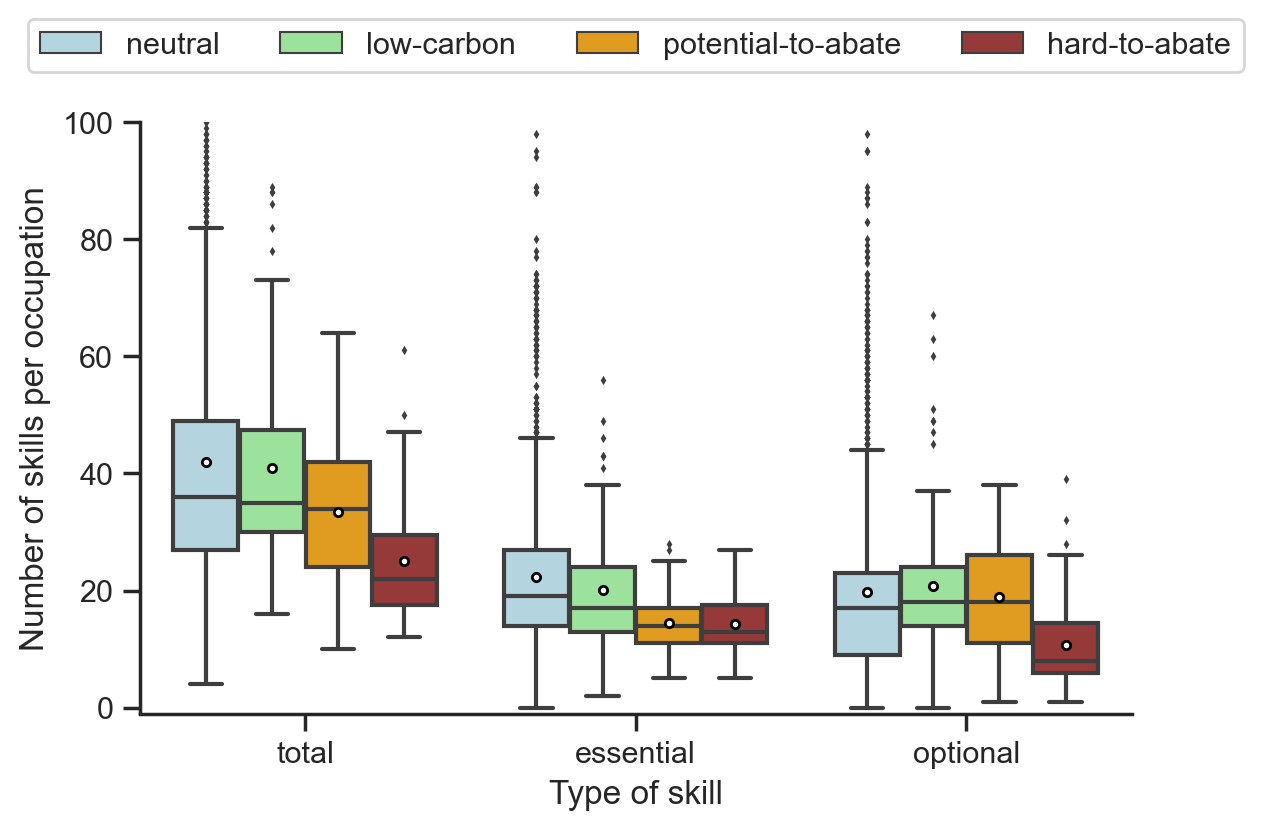

In [29]:
new_pal = {"neutral": "lightblue", "low-carbon": "lightgreen", "potential-to-abate":"orange", "hard-to-abate": "brown"}
hue_order = list(new_pal.keys())
hue_colors = list(new_pal.values())

ax = sns.boxplot(
    data=n_skills_by_cat_long,
    x="skill_type",
    y="skills",
    hue="classification",
    hue_order = hue_order,
    fliersize=1,
    showmeans=True,
    meanprops=meanprops,
    palette=hue_colors
)

ax.set_xlabel("Type of skill")
ax.set_ylabel("Number of skills per occupation")

ax.set_ylim(-1, 100)
#plotting_utils.move_legend_to_right(ax)
plotting_utils.move_legend_to_top(ax=ax, ncol=4, upper_anchor=1.2)
sns.despine()

# save
#plt.tight_layout(h_pad=1.2)
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "n_skills_by_{}.png".format(gbn_clsf),
    ),
    dpi=300,
)

In [30]:
fig2_stats = n_skills_by_cat_long.set_index(['preferredLabel']).groupby(['skill_type', 'classification']).agg([np.mean, np.median, np.min, np.max])
fig2_stats.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "fig2_descriptive_stats_skill_number.csv",
    ),
)

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_11368\359836734.py:1: FutureWarning: The provided callable <function mean at 0x000001D9C1CBBEC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  fig2_stats = n_skills_by_cat_long.set_index(['preferredLabel']).groupby(['skill_type', 'classification']).agg([np.mean, np.median, np.min, np.max])
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_11368\359836734.py:1: FutureWarning: The provided callable <function median at 0x000001D9C1DF9D00> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  fig2_stats = n_skills_by_cat_long.set_index(['preferredLabel']).groupby(['skill_type', 'classification']).agg([np.mean, np.median, np.min, np.max])
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_

In [31]:
pvalue_thresholds=[[0.001, '****'], [0.01, '***'], [0.05, '**'], [0.1, '*'], [1, 'ns']]

Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 5.00e-02 < p <= 1.00e-01
      **: 1.00e-02 < p <= 5.00e-02
     ***: 1.00e-03 < p <= 1.00e-02
    ****: p <= 1.00e-03

optional_potential-to-abate vs. optional_hard-to-abate: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.504e-09 Stat=3.653e+01
essential_potential-to-abate vs. essential_hard-to-abate: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.326e-01 Stat=6.160e-01
optional_neutral vs. optional_low-carbon: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.233e-02 Stat=4.581e+00
total_potential-to-abate vs. total_hard-to-abate: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.697e-06 Stat=2.202e+01
total_low-carbon vs. total_potential-to-abate: Kruskal-Wallis independent samples (pairwise between g

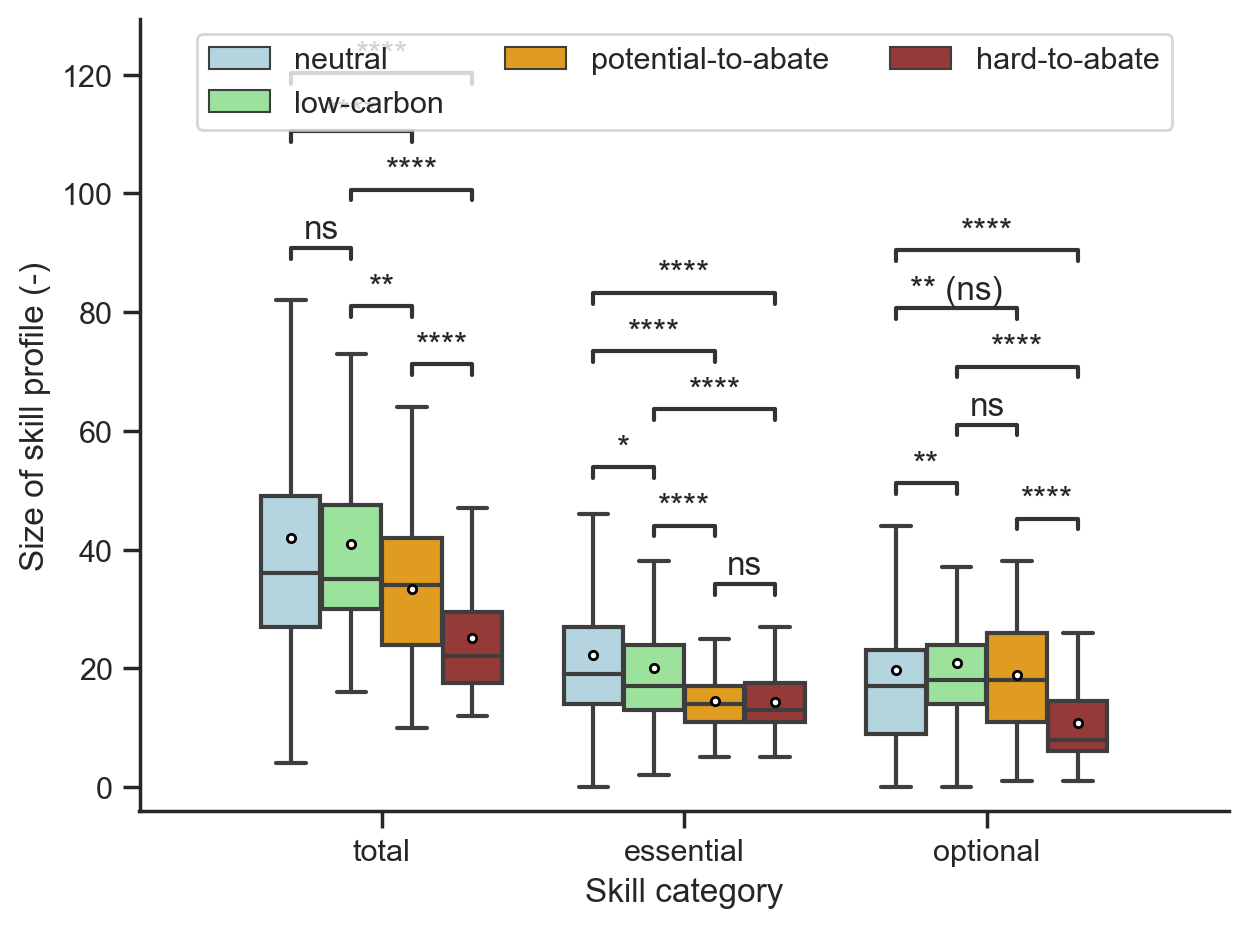

In [32]:
# configure
x = "skill_type"
y = "skills"
hue = "classification"
df_plot = n_skills_by_cat_long
order = ["total", "essential", "optional"]
hue_order = list(new_pal.keys())
hue_colors = list(new_pal.values())

pairs = [
    # total
    (("total", "low-carbon"), ("total", "potential-to-abate")),
    (("total", "low-carbon"), ("total", "hard-to-abate")),
    (("total", "low-carbon"), ("total", "neutral")),
    (("total", "potential-to-abate"), ("total", "hard-to-abate")),
    (("total", "potential-to-abate"), ("total", "neutral")),
    (("total", "hard-to-abate"), ("total", "neutral")),
    # essential
    (("essential", "low-carbon"), ("essential", "potential-to-abate")),
    (("essential", "low-carbon"), ("essential", "hard-to-abate")),
    (("essential", "low-carbon"), ("essential", "neutral")),
    (("essential", "potential-to-abate"), ("essential", "hard-to-abate")),
    (("essential", "potential-to-abate"), ("essential", "neutral")),
    (("essential", "hard-to-abate"), ("essential", "neutral")),
    # optional
    (("optional", "low-carbon"), ("optional", "potential-to-abate")),
    (("optional", "low-carbon"), ("optional", "hard-to-abate")),
    (("optional", "low-carbon"), ("optional", "neutral")),
    (("optional", "potential-to-abate"), ("optional", "hard-to-abate")),
    (("optional", "potential-to-abate"), ("optional", "neutral")),
    (("optional", "hard-to-abate"), ("optional", "neutral")),
]

# plot
# f, ax = plt.subplots(figsize=(10, 10))
ax = sns.boxplot(
    data=df_plot,
    x=x,
    y=y,
    hue=hue,
    fliersize=1,
    order=order,
    hue_order=hue_order,
    palette=hue_colors,
    showmeans=True,
    meanprops=meanprops,
    width=0.8,
    showfliers=False,
)
plotting_utils.move_legend_to_top(ax, scale=1, ncol=3, upper_anchor=1)
sns.despine()

# test statistic
annotator = Annotator(
    ax, pairs, data=df_plot, x=x, y=y, order=order, hue=hue, hue_order=hue_order
)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="star",
    loc="inside",
    show_test_name=False,
    pvalue_thresholds=pvalue_thresholds
)
annotator.apply_and_annotate()

# label
ax.set_ylabel("Size of skill profile (-)")
ax.set_xlabel("Skill category")

# save
plt.tight_layout(w_pad=1.2)
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "n_skills_by_{}_statsannot.png".format(gbn_clsf),
    ),
    dpi=300,
)

In [33]:
import scikit_posthocs as sp

res = []
for skill_type in ["total", "essential", "optional"]:
    skill_type_query = "'" + "{}".format(skill_type) + "'"
    dfm = n_skills_by_cat_long.query("skill_type == {}".format(skill_type_query))

    pvals = (
        sp.posthoc_dunn(
            dfm, val_col="skills", group_col="classification", p_adjust="bonferroni"
        )
        .unstack()
        .rename(skill_type)
    )

    res.append(pvals)

posthoc_dunn = pd.concat(res, axis=1)
posthoc_dunn

total     essential  \
hard-to-abate      hard-to-abate       1.000000e+00  1.000000e+00   
                   low-carbon          2.563536e-09  5.128573e-04   
                   neutral             4.474287e-14  5.914313e-10   
                   potential-to-abate  4.115997e-05  1.000000e+00   
low-carbon         hard-to-abate       2.563536e-09  5.128573e-04   
                   low-carbon          1.000000e+00  1.000000e+00   
                   neutral             1.000000e+00  5.410725e-01   
                   potential-to-abate  6.138836e-02  6.664874e-05   
neutral            hard-to-abate       4.474287e-14  5.914313e-10   
                   low-carbon          1.000000e+00  5.410725e-01   
                   neutral             1.000000e+00  1.000000e+00   
                   potential-to-abate  1.610921e-03  1.444283e-18   
potential-to-abate hard-to-abate       4.115997e-05  1.000000e+00   
                   low-carbon          6.138836e-02  6.664874e-05   
                   neutral             1.610921e-03  1.444283e-18   
                   potential-to-abate  1.000000e+00  1.000000e+00   

                                           optional  
hard-to-abate      hard-to-abate       1.000000e+00  
                   low-carbon          2.502921e-07  
                   neutral             9.461655e-07  
                   potential-to-abate  1.651722e-07  
low-carbon         hard-to-abate       2.502921e-07  
                   low-carbon          1.000000e+00  
                   neutral             1.834128e-01  
                   potential-to-abate  1.000000e+00  
neutral            hard-to-abate       9.461655e-07  
                   low-carbon          1.834128e-01  
                   neutral             1.000000e+00  
                   potential-to-abate  2.725564e-01  
potential-to-abate hard-to-abate       1.651722e-07  
                   low-carbon          1.000000e+00  
                   neutral             2.725564e-01  
                   potential-to-abate  1.000000e+00

In [34]:
res = []
for skill_type in ["total", "essential", "optional"]:
    skill_type_query = "'" + "{}".format(skill_type) + "'"
    dfm = n_skills_by_cat_long.query("skill_type == {}".format(skill_type_query))

    pvals = (
        sp.posthoc_ttest(
            dfm, val_col="skills", group_col="classification", p_adjust="bonferroni"
        )
        .unstack()
        .rename(skill_type)
    )

    res.append(pvals)

posthoc_ttest = pd.concat(res, axis=1)
posthoc_ttest

total     essential  \
neutral            neutral             1.000000e+00  1.000000e+00   
                   potential-to-abate  4.627096e-04  6.826690e-13   
                   hard-to-abate       1.337073e-06  2.779411e-06   
                   low-carbon          1.000000e+00  5.984283e-01   
potential-to-abate neutral             4.627096e-04  6.826690e-13   
                   potential-to-abate  1.000000e+00  1.000000e+00   
                   hard-to-abate       2.294183e-05  1.000000e+00   
                   low-carbon          9.852618e-04  8.801533e-08   
hard-to-abate      neutral             1.337073e-06  2.779411e-06   
                   potential-to-abate  2.294183e-05  1.000000e+00   
                   hard-to-abate       1.000000e+00  1.000000e+00   
                   low-carbon          9.673073e-09  1.497001e-04   
low-carbon         neutral             1.000000e+00  5.984283e-01   
                   potential-to-abate  9.852618e-04  8.801533e-08   
                   hard-to-abate       9.673073e-09  1.497001e-04   
                   low-carbon          1.000000e+00  1.000000e+00   

                                           optional  
neutral            neutral             1.000000e+00  
                   potential-to-abate  1.000000e+00  
                   hard-to-abate       9.540599e-03  
                   low-carbon          1.000000e+00  
potential-to-abate neutral             1.000000e+00  
                   potential-to-abate  1.000000e+00  
                   hard-to-abate       2.537076e-08  
                   low-carbon          1.000000e+00  
hard-to-abate      neutral             9.540599e-03  
                   potential-to-abate  2.537076e-08  
                   hard-to-abate       1.000000e+00  
                   low-carbon          7.667270e-07  
low-carbon         neutral             1.000000e+00  
                   potential-to-abate  1.000000e+00  
                   hard-to-abate       7.667270e-07  
                   low-carbon          1.000000e+00

#### Differences in skills centrality

DF with Expert classification

In [35]:
df.head()

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list_sl,gbn_classification_short_list_slt,expert_classification
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,Technical directors realise the artistic visio...,neutral,neutral,neutral,neutral,neutral
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,Video and motion picture directors are respons...,neutral,neutral,neutral,neutral,neutral
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,Performance lighting directors determine what ...,neutral,neutral,neutral,neutral,neutral
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,Animation directors supervise and recruit mult...,neutral,neutral,neutral,neutral,neutral
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,Video and motion picture producers supervise t...,neutral,neutral,neutral,neutral,neutral


DF with skill-level network metrics

In [36]:
smd.head()

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness,skill_classification_esco
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,manage staff of music\ncoordinate duties of mu...,NaN,released,2016-12-20T17:43:43Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Assign and manage staff tasks in areas such as...,0.008913,407.745181,0.000155,0.004534,0.667955,0.001775,neutral
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,oversee prison procedures\nmanage correctional...,NaN,released,2016-12-20T20:17:49Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Supervise the operations of a correctional fac...,0.011462,0.000000,0.000000,0.005731,1.000000,0.000000,neutral
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,apply non-oppressive practices\napply an anti-...,NaN,released,2016-12-20T19:18:19Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Identify oppression in societies, economies, c...",0.099058,42.006206,0.000016,0.049537,0.910226,0.005243,neutral
3,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0007bdc2-dd15...,skill/competence,sector-specific,control compliance of railway vehicles regulat...,monitoring of compliance with railway vehicles...,NaN,released,2016-12-20T20:02:19Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Inspect rolling stock, components and systems ...",0.224835,910.063993,0.000347,0.112591,0.593705,0.053932,neutral
4,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00090cc1-1f27...,skill/competence,cross-sector,identify available services,establish available services\ndetermine rehabi...,NaN,released,2016-12-20T20:15:17Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Identify the different services available for ...,0.014832,8.790779,0.000003,0.007418,0.843977,0.001364,neutral


DF with OSM

In [37]:
df_network_metrics_by_occ = pd.DataFrame(index=osm.index)
df_network_metrics_by_occ

""
conceptUri
http://data.europa.eu/esco/occupation/00030d09-2b3a-4efd-87cc-c4ea39d27c34
http://data.europa.eu/esco/occupation/000e93a3-d956-4e45-aacb-f12c83fedf84
http://data.europa.eu/esco/occupation/0019b951-c699-4191-8208-9822882d150c
http://data.europa.eu/esco/occupation/0022f466-426c-41a4-ac96-a235c945cf97
http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f
...
http://data.europa.eu/esco/occupation/ff656b3a-65a8-4b4f-b04e-9db12936519b
http://data.europa.eu/esco/occupation/ff8d4065-db44-47c7-a4bd-51b3c306ef70
http://data.europa.eu/esco/occupation/ffa4dd5d-702b-4828-ad85-17ec50db6656


In [38]:
%time
# iterate over network metrics
network_metrics = [
    "eigenvector_centrality",
    "betweenness_centrality",
    "betweenness_centrality_norm",
    "mean_centrality",
    "clustering_coefficient",
    "coreness"
]

for network_metric in network_metrics:
    # tile skill-level network metrics to match OSM
    network_metric_tiled = np.tile(smd[network_metric].values, (3008, 1))
    
    # multiply with OSM
    osm_network_metric = network_metric_tiled * osm_wtd

    # aggregate by taking mean across skills, weighted by skill importance
    osm_network_metric_agg = osm_network_metric.mean(axis=1)

    # append to empty df
    df_network_metrics_by_occ["{}_mean".format(network_metric)] = osm_network_metric_agg

CPU times: total: 0 ns
Wall time: 0 ns


In [39]:
df_network_metrics_by_occ

,eigenvector_centrality_mean,betweenness_centrality_mean,betweenness_centrality_norm_mean,mean_centrality_mean,clustering_coefficient_mean,coreness_mean
conceptUri,,,,,,
http://data.europa.eu/esco/occupation/00030d09-2b3a-4efd-87cc-c4ea39d27c34,0.000033,6.246123,0.000002,0.000018,0.000260,0.000013
http://data.europa.eu/esco/occupation/000e93a3-d956-4e45-aacb-f12c83fedf84,0.000543,345.010330,0.000131,0.000337,0.000663,0.000330
http://data.europa.eu/esco/occupation/0019b951-c699-4191-8208-9822882d150c,0.000733,298.069110,0.000114,0.000423,0.000776,0.000367
http://data.europa.eu/esco/occupation/0022f466-426c-41a4-ac96-a235c945cf97,0.000466,65.749117,0.000025,0.000245,0.000830,0.000197
http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f,0.000438,355.861241,0.000136,0.000287,0.000600,0.000279
...,...,...,...,...,...,...
http://data.europa.eu/esco/occupation/ff656b3a-65a8-4b4f-b04e-9db12936519b,0.001872,558.062181,0.000213,0.001042,0.000886,0.001027
http://data.europa.eu/esco/occupation/ff8d4065-db44-47c7-a4bd-51b3c306ef70,0.000220,97.809990,0.000037,0.000129,0.000442,0.000119
http://data.europa.eu/esco/occupation/ffa4dd5d-702b-4828-ad85-17ec50db6656,0.000112,44.802398,0.000017,0.000064,0.000626,0.000055


In [40]:
# merge with original df
df_network_metrics = pd.merge(df, df_network_metrics_by_occ.reset_index(), on='conceptUri', how='left')
df_network_metrics = df_network_metrics.loc[:, ~df_network_metrics.columns.str.startswith('gbn')].rename(columns={gbn_clsf: "classification"})
df_network_metrics.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "mean_network_metrics_by_{}.csv".format(gbn_clsf),
    ),
)

In [41]:
nm_cols = ['eigenvector_centrality_mean', 'betweenness_centrality_mean',
       'betweenness_centrality_norm_mean', 'mean_centrality_mean',
       'clustering_coefficient_mean', 'coreness_mean']

df_network_metrics

,conceptUri,preferredLabel,description,classification,eigenvector_centrality_mean,betweenness_centrality_mean,betweenness_centrality_norm_mean,mean_centrality_mean,clustering_coefficient_mean,coreness_mean
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,Technical directors realise the artistic visio...,neutral,0.000033,6.246123,0.000002,0.000018,0.000260,0.000013
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,Video and motion picture directors are respons...,neutral,0.000167,42.155227,0.000016,0.000091,0.000867,0.000077
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,Performance lighting directors determine what ...,neutral,0.000340,236.804101,0.000090,0.000215,0.000800,0.000208
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,Animation directors supervise and recruit mult...,neutral,0.000564,399.805999,0.000152,0.000358,0.000634,0.000347
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,Video and motion picture producers supervise t...,neutral,0.000517,318.052903,0.000121,0.000319,0.000775,0.000309
...,...,...,...,...,...,...,...,...,...,...
3003,http://data.europa.eu/esco/occupation/b059d331...,hawker,Hawkers sell goods and services on established...,neutral,0.000440,309.373677,0.000118,0.000279,0.001165,0.000250
3004,http://data.europa.eu/esco/occupation/96a0d8d3...,quick service restaurant crew member,"Quick service restaurant crew members prepare,...",neutral,0.000125,96.276435,0.000037,0.000081,0.000632,0.000078
3005,http://data.europa.eu/esco/occupation/a02a1117...,pizzaiolo,Pizzaiolos are responsible for preparing and c...,neutral,0.000117,128.384732,0.000049,0.000083,0.000561,0.000082
3006,http://data.europa.eu/esco/occupation/e1cf6897...,kitchen assistant,Kitchen assistants assist in the preparation o...,neutral,0.000129,114.516241,0.000044,0.000086,0.000867,0.000083


In [42]:
df_network_metrics_long = pd.melt(df_network_metrics, id_vars=['classification'], value_vars=nm_cols)
fig2_stats2 = df_network_metrics_long.groupby(['variable', 'classification']).agg([np.mean, np.median, np.min, np.max])

fig2_stats2.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "fig2_descriptive_stats_skill_metrics.csv",
    ),
)

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_11368\342981537.py:2: FutureWarning: The provided callable <function mean at 0x000001D9C1CBBEC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  fig2_stats2 = df_network_metrics_long.groupby(['variable', 'classification']).agg([np.mean, np.median, np.min, np.max])
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_11368\342981537.py:2: FutureWarning: The provided callable <function median at 0x000001D9C1DF9D00> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  fig2_stats2 = df_network_metrics_long.groupby(['variable', 'classification']).agg([np.mean, np.median, np.min, np.max])
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_11368\342981537.py:2: FutureWarning: The provided callab

In [43]:
# plot
for nm_col in nm_cols:

    ci95 = df_network_metrics[nm_col].quantile(0.99)
    
    fig, ax = plt.subplots(figsize=(3,3))
    ax.ticklabel_format(axis='both', style='scientific', scilimits=(0, 0))
    sns.boxplot(
        data=df_network_metrics,
        x="classification",
        y=nm_col,
        fliersize=1,
        showmeans=True,
        meanprops=meanprops,
        palette=hue_colors,
        width=0.9,
        ax=ax
    )
    
    ax.set_xlabel(None)
    ax.set_ylabel(nm_col)
    sns.despine()
    ax.set_ylim(0, ci95)

    # save
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "skills_centrality",
            "{}_by_{}.png".format(nm_col, gbn_clsf),
        ),
        dpi=300,
    )
    plt.close()

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype

single plot for coreness metric

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


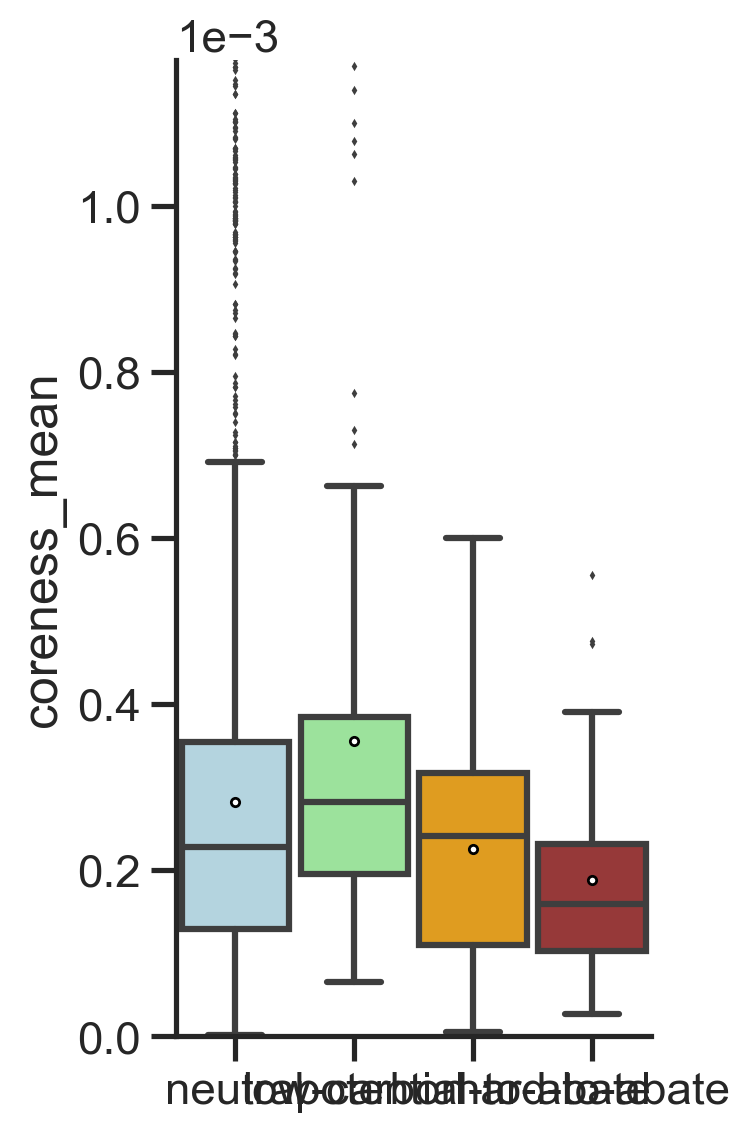

In [44]:
sns.set_context("talk")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

nm_col='coreness_mean'
ci95 = df_network_metrics[nm_col].quantile(0.99)

fig, ax = plt.subplots(figsize=(4, 6))
ax.ticklabel_format(axis='both', style='scientific', scilimits=(0, 0))
sns.boxplot(
    data=df_network_metrics,
    x="classification",
    y=nm_col,
    fliersize=1,
    showmeans=True,
    meanprops=meanprops,
    palette=hue_colors,
    width=.9,
    ax=ax
)

ax.set_xlabel(None)
ax.set_ylabel(nm_col)
sns.despine()
ax.set_ylim(0, ci95)

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "{}_by_{}_large.png".format(nm_col, gbn_clsf),
    ),
    dpi=300,
)


C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype

neutral vs. low-carbon: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:6.048e-04 Stat=1.176e+01
low-carbon vs. potential-to-abate: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.611e-04 Stat=1.227e+01
potential-to-abate vs. hard-to-abate: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:7.419e-02 Stat=3.188e+00


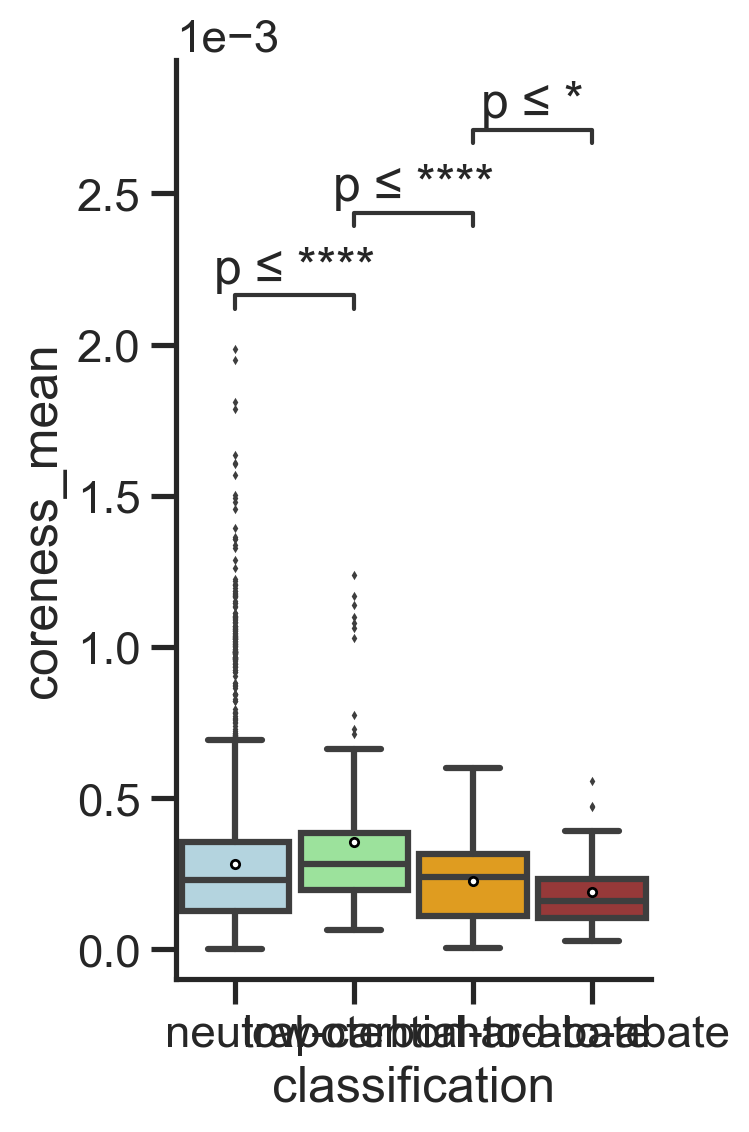

In [45]:
pairs = [
    ("neutral", "low-carbon"),
    ("low-carbon", "potential-to-abate"),
    ("hard-to-abate", "potential-to-abate"),
]

# plot
fig, ax = plt.subplots(figsize=(4, 6))
ax.ticklabel_format(axis='both', style='scientific', scilimits=(0, 0))

sns.boxplot(
    data=df_network_metrics,
    x="classification",
    y=nm_col,
    fliersize=1,
    showmeans=True,
    meanprops=meanprops,
    palette=hue_colors,
    width=.9,
    ax=ax
)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df_network_metrics, x="classification", y=nm_col)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="simple",
    loc="inside",
    show_test_name=False,
    pvalue_thresholds=pvalue_thresholds
)
annotator.apply_and_annotate()

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "{}_by_{}_large_statannot.png".format(nm_col, gbn_clsf),
    ),
    dpi=300,
)


In [46]:
pairs

[('neutral', 'low-carbon'),
 ('low-carbon', 'potential-to-abate'),
 ('hard-to-abate', 'potential-to-abate')]

In [47]:
df_network_metrics.groupby('classification').count()

,conceptUri,preferredLabel,description,eigenvector_centrality_mean,betweenness_centrality_mean,betweenness_centrality_norm_mean,mean_centrality_mean,clustering_coefficient_mean,coreness_mean
classification,,,,,,,,,
hard-to-abate,63,63,63,63,63,63,63,63,63
low-carbon,91,91,91,91,91,91,91,91,91
neutral,2710,2710,2710,2710,2710,2710,2710,2710,2710
potential-to-abate,144,144,144,144,144,144,144,144,144


In [48]:
df_network_metrics[nm_col].quantile(0.75)

0.0003500854102595513

In [49]:
nm_cols

['eigenvector_centrality_mean',
 'betweenness_centrality_mean',
 'betweenness_centrality_norm_mean',
 'mean_centrality_mean',
 'clustering_coefficient_mean',
 'coreness_mean']

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


ValueError: Could not interpret input 'eigenvector_centrality_mean'

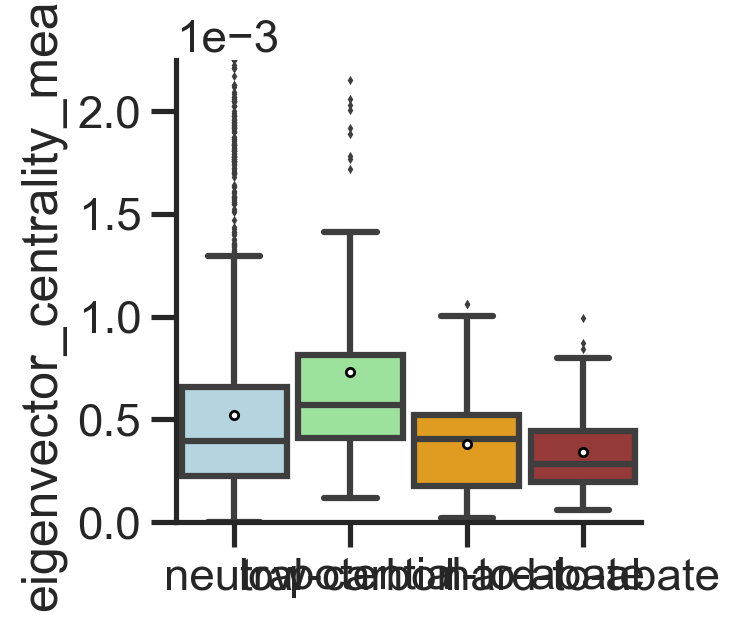

In [50]:
# with annotations

pairs = [
    # total
    ("low-carbon", "potential-to-abate"),
    ("low-carbon", "hard-to-abate"),
    ("low-carbon", "neutral"),
    ("potential-to-abate", "hard-to-abate"),
    ("potential-to-abate", "neutral"),
    ("hard-to-abate", "neutral"),
]
order = ["neutral", "low-carbon", "potential-to-abate", "hard-to-abate"]

for nm_col in nm_cols:

    ci95 = df_network_metrics[nm_col].quantile(0.99)

    x="classification"
    y=nm_col
    
    fig, ax = plt.subplots(figsize=(3,3))
    ax.ticklabel_format(axis='both', style='scientific', scilimits=(0, 0))
    sns.boxplot(
        data=df_network_metrics,
        x=x,
        y=y,
        fliersize=1,
        showmeans=True,
        meanprops=meanprops,
        palette=hue_colors,
        width=0.9,
        ax=ax
    )
    
    ax.set_xlabel(None)
    ax.set_ylabel(nm_col)
    sns.despine()
    ax.set_ylim(0, ci95)

    # test statistic
    annotator = Annotator(
        ax, pairs, data=df_plot, x=x, y=y , order=order #, hue=hue, hue_order=hue_order
    )
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="star",
        loc="inside",
        show_test_name=False,
        pvalue_thresholds=pvalue_thresholds
    )
    annotator.apply_and_annotate()

    # save
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "skills_centrality",
            "{}_by_{}_statannot.png".format(nm_col, gbn_clsf),
        ),
        dpi=300,
    )
    plt.close()

OLD CODE FROM DEC 2022

In [ ]:
osm_coreness_merged = pd.concat([osm_coreness, df[colsel]], axis=1)

In [ ]:
osm_coreness_merged
osm_coreness

In [ ]:
osm_coreness_merged_v2 = osm_coreness_merged.reset_index().set_index(
    ["conceptUri", "preferredLabel", gbn_clsf]
)

Aggregate by mean or median?
--> distribution very right-skewed, use median

In [ ]:
coreness_1d = osm_coreness_merged_v2[osm_coreness_merged_v2 > 0].stack()
coreness_1d.hist(bins=30)

In [ ]:
osm_coreness_merged_v2_agg = pd.concat(
    [
        osm_coreness_merged_v2[osm_coreness_merged_v2 > 0]
        .mean(axis=1)
        .rename("coreness_mean"),
        osm_coreness_merged_v2[osm_coreness_merged_v2 > 0]
        .median(axis=1)
        .rename("coreness_median"),
    ],
    axis=1,
)

osm_coreness_merged_v2_agg = osm_coreness_merged_v2_agg.reset_index()
osm_coreness_merged_v2_agg = osm_coreness_merged_v2_agg.rename(
    columns={gbn_clsf: "classification"}
)

Statsannotations: t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal

The Shapiro-Wilk test. This test compares our distribution with a normal distribution (like in our plot) and tells us whether our distribution is significantly different from it. Thus, if the test is not significant, the distribution of our data is not significantly different from a normal distribution, or in simple terms: It is normally distributed.

https://bookdown.org/daniel_dauber_io/r4np_book/sources-of-bias.html

In [ ]:
osm_coreness_merged_v2_agg.hist()

In [ ]:
print("median: ", stats.shapiro(osm_coreness_merged_v2_agg.coreness_median))
print("mean: ", stats.shapiro(osm_coreness_merged_v2_agg.coreness_mean))

Coreness not normally distributed --> use non-parametric tests

In [ ]:
# configure
x = "classification"
y = "coreness_median"
df = osm_coreness_merged_v2_agg
order = ["green", "brown", "neutral"]
pairs = [("green", "brown"), ("green", "neutral"), ("brown", "neutral")]

# plot
ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    fliersize=1,
    order=order,
    palette=["lightgreen", "orange", "grey"],
    showmeans=True,
    meanprops=meanprops,
    width=0.5,
)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="simple",
    loc="inside",
    show_test_name=False,
)
annotator.apply_and_annotate()

# label
ax.set_ylabel("Skills coreness (-)")
ax.set_xlabel("Occupation category")

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "median_skills_coreness_by_{}.png".format(gbn_clsf),
    ),
    dpi=300,
)

Cohen's D suggests medium effect size

In [ ]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'green'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'brown'").coreness_median,
)

In [ ]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'green'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'neutral'").coreness_median,
)

In [ ]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'brown'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'neutral'").coreness_median,
)

In [ ]:
sns.histplot(osm_coreness_merged_v2_agg, x="coreness_median", hue="classification")

In [ ]:
# configure
x = "classification"
y = "coreness_mean"
df = osm_coreness_merged_v2_agg
order = ["green", "brown", "neutral"]
pairs = [("green", "brown"), ("green", "neutral"), ("brown", "neutral")]

# plot
ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    fliersize=1,
    order=order,
    palette=["lightgreen", "orange", "grey"],
    showmeans=True,
    meanprops=meanprops,
)
plotting_utils.move_legend_to_right(ax)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="simple",
    loc="outside",
    show_test_name=False,
)
annotator.apply_and_annotate()

In [ ]:
smd.columns

In [ ]:
smd

In [ ]:
network_metrics = [
    "eigenvector_centrality",
    "betweenness_centrality",
    "betweenness_centrality_norm",
    "mean_centrality",
    "clustering_coefficient",
    "coreness",
    "skill_classification_esco",
]

# configure
x = "skill_classification_esco"
# y = "coreness"
df = smd
order = ["green", "brown", "neutral"]
pairs = [("green", "brown"), ("green", "neutral"), ("brown", "neutral")]

for y in network_metrics:
    # plot
    ax = sns.boxplot(
        data=df,
        x=x,
        y=y,
        fliersize=1,
        order=order,
        palette=["lightgreen", "orange", "grey"],
        showmeans=True,
        meanprops=meanprops,
        showfliers=False,
    )
    plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # add test statistics
    annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

    # labelling
    ax.set_ylabel("{} (-)".format(y))
    ax.set_xlabel("Skill classification")

    # save
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "skills_centrality",
            "skills_{}_by_{}.png".format(y, gbn_clsf),
        ),
        dpi=300,
    )
    plt.clf()